<a href="https://colab.research.google.com/github/booogieeee/DarkMap/blob/main/ML_MAPPING_TOOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies!pip install earthaccess rasterio h5py numpy matplotlib -q

import earthaccess
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("All packages loaded ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 106.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is incompatible.
All packages loaded ✓


In [ ]:
auth = earthaccess.login(strategy="interactive")


In [ ]:
kampong_speu_bbox = (103.5, 10.9, 104.6, 11.8)

results = earthaccess.search_data(
    short_name="VNP46A2",
    temporal=("2023-01-01", "2023-12-31"),
    bounding_box=kampong_speu_bbox
)

print(f"Found {len(results)} granules")

Found 362 granules


/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [ ]:
files = earthaccess.download(results[:5], local_path="./viirs_data/")
print("Downloaded:", files)

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/5 [00:00<?, ?it/s]

Downloaded: [PosixPath('viirs_data/VNP46A2.A2022365.h28v07.002.2025135012420.h5'), PosixPath('viirs_data/VNP46A2.A2023001.h28v07.002.2025135151858.h5'), PosixPath('viirs_data/VNP46A2.A2023002.h28v07.002.2025135163855.h5'), PosixPath('viirs_data/VNP46A2.A2023003.h28v07.002.2025135165901.h5'), PosixPath('viirs_data/VNP46A2.A2023004.h28v07.002.2025135171804.h5')]


In [ ]:
import h5py
import numpy as np
import rasterio
from rasterio.transform import from_bounds
import os


hdf_files = [f for f in os.listdir("./viirs_data/") if f.endswith(".h5")]
print("Found files:", hdf_files)

Found files: ['VNP46A2.A2022365.h28v07.002.2025135012420.h5', 'VNP46A2.A2023002.h28v07.002.2025135163855.h5', 'VNP46A2.A2023001.h28v07.002.2025135151858.h5', 'VNP46A2.A2023004.h28v07.002.2025135171804.h5', 'VNP46A2.A2023003.h28v07.002.2025135165901.h5']


In [ ]:
with h5py.File(f"./viirs_data/{hdf_files[0]}", "r") as f:

    grids = f["HDFEOS/GRIDS/"]
    print("Grids available:", list(grids.keys()))


    first_grid = list(grids.keys())[0]
    print("Data fields:", list(f[f"HDFEOS/GRIDS/{first_grid}/Data Fields/"].keys()))

Grids available: ['VIIRS_Grid_DNB_2d']
Data fields: ['DNB_BRDF-Corrected_NTL', 'DNB_Lunar_Irradiance', 'Gap_Filled_DNB_BRDF-Corrected_NTL', 'Latest_High_Quality_Retrieval', 'Mandatory_Quality_Flag', 'QF_Cloud_Mask', 'Snow_Flag', 'lat', 'lon']


In [ ]:
with h5py.File(f"./viirs_data/{hdf_files[0]}", "r") as f:

    ntl = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL"][:]


    fill_value = f["HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/Gap_Filled_DNB_BRDF-Corrected_NTL"].attrs.get("_FillValue", 65535)

    print("Array shape:", ntl.shape)
    print("Data type:", ntl.dtype)
    print("Min value:", ntl.min())
    print("Max value:", ntl.max())
    print("Fill value:", fill_value)

Array shape: (2400, 2400)
Data type: float32
Min value: 4.263174e-07
Max value: 1799.6931
Fill value: [-999.9]


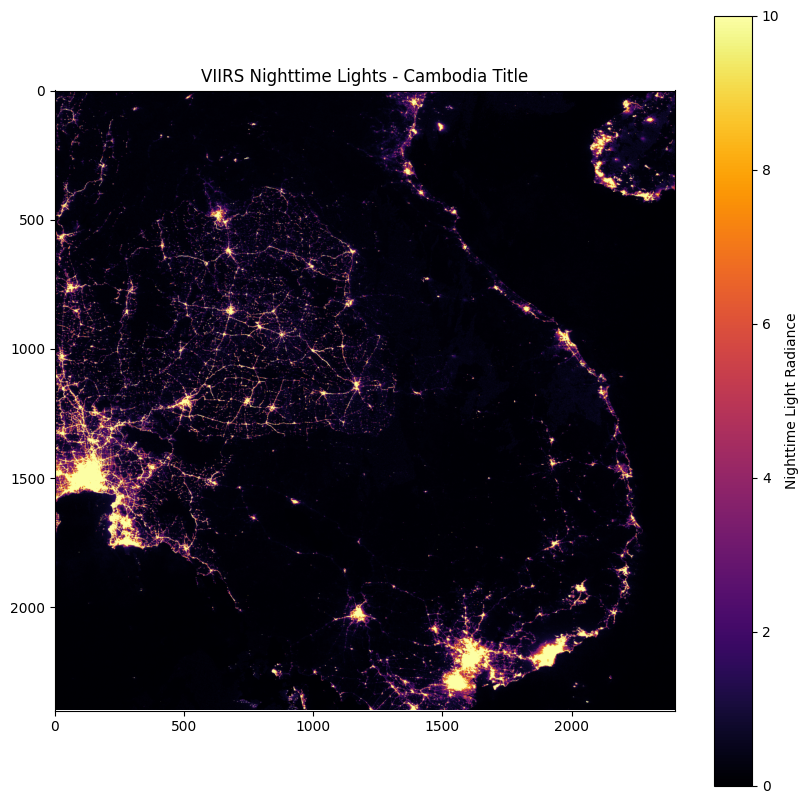

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ntl_clean = np.where(ntl == -999.9, np.nan, ntl)

plt.figure(figsize=(10,10))
plt.imshow(ntl_clean, cmap="inferno", vmin=0, vmax=10)
plt.colorbar(label="Nighttime Light Radiance")
plt.title("VIIRS Nighttime Lights - Cambodia Title")
plt.show()

Cropped shape: (217, 263)


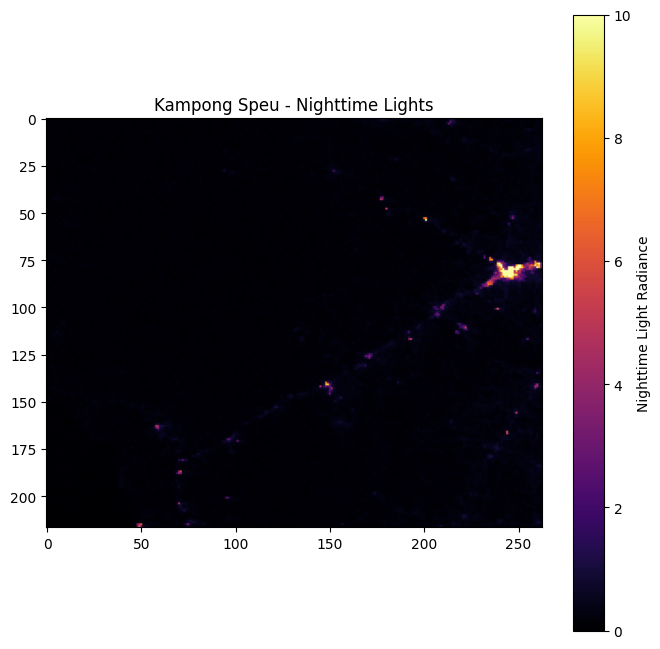

In [ ]:

lat_min, lat_max = 10.9, 11.8
lon_min, lon_max = 103.5, 104.6


tile_lat_max = 20.0
tile_lat_min = 10.0
tile_lon_min = 100.0
tile_lon_max = 110.0


row_min = int((tile_lat_max - lat_max) / (tile_lat_max - tile_lat_min) * 2400)
row_max = int((tile_lat_max - lat_min) / (tile_lat_max - tile_lat_min) * 2400)
col_min = int((lon_min - tile_lon_min) / (tile_lon_max - tile_lon_min) * 2400)
col_max = int((lon_max - tile_lon_min) / (tile_lon_max - tile_lon_min) * 2400)

# Crop
kampong_speu = ntl_clean[row_min:row_max, col_min:col_max]

print(f"Cropped shape: {kampong_speu.shape}")
plt.figure(figsize=(8, 8))
plt.imshow(kampong_speu, cmap="inferno", vmin=0, vmax=10)
plt.colorbar(label="Nighttime Light Radiance")
plt.title("Kampong Speu - Nighttime Lights")
plt.show()

In [ ]:
from rasterio.transform import from_bounds
import rasterio
import numpy as np

# Define the geographic bounds of our cropped Kampong Speu area
lon_min, lat_min = 103.5, 10.9
lon_max, lat_max = 104.6, 11.8

# Create a transformation matrix that maps pixels to GPS coordinates
transform = from_bounds(lon_min, lat_min, lon_max, lat_max,
                        kampong_speu.shape[1], kampong_speu.shape[0])

# Save as GeoTIFF
output_path = "./viirs_data/kampong_speu_ntl.tif"

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',        # file format
    height=kampong_speu.shape[0],
    width=kampong_speu.shape[1],
    count=1,               # number of bands (1 = grayscale)
    dtype='float32',
    crs='EPSG:4326',       # standard GPS coordinate system
    transform=transform
) as dst:
    dst.write(np.nan_to_num(kampong_speu, nan=-999.9), 1)

print(f"Saved to {output_path}")

Saved to ./viirs_data/kampong_speu_ntl.tif
